# 06 kmeans clustering

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import shap

## load processed dataset

Using all features gives no clear clusters (silhouette ~0.12). These 5 per-capita lifestyle features expose real structure (silhouette ~0.55).

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

# 5 per-capita lifestyle features (full feature set gives no clear clusters — see notes above)
feature_cols = [
    "energy_per_person", "car_per_person",
    "meat_per_person", "food_per_person", "gas_per_person"
]

X = df[feature_cols].copy()


## scaling

In [4]:
scaler = StandardScaler()  # KMeans is distance-based
X_scaled = scaler.fit_transform(X)  # z-score normalisation

## elbow method

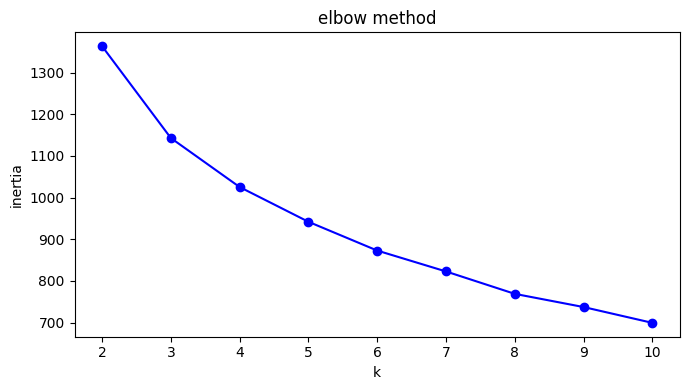

In [5]:
inertias = []
ks = range(2, 11)  # sweep k from 2 to 10

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)  # total within-cluster sum of squared distances

plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, "bo-")
plt.xlabel("k"); plt.ylabel("inertia")
plt.title("elbow method")
plt.tight_layout()
plt.show()

Elbow is soft — no single obvious k.

## silhouette scores

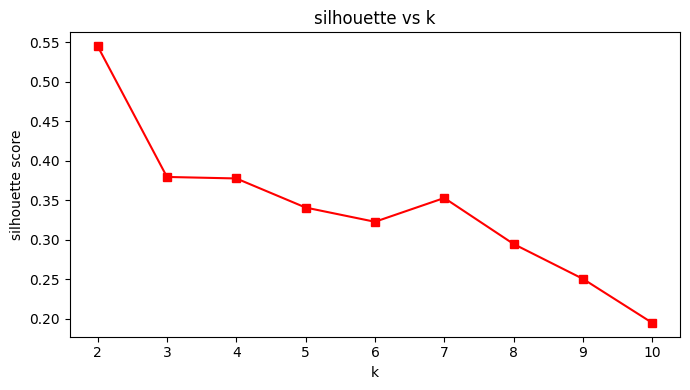

best k by silhouette: 2


In [6]:
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))  # higher = better-separated clusters (-1 to 1)

plt.figure(figsize=(7, 4))
plt.plot(ks, sil_scores, "rs-")
plt.xlabel("k"); plt.ylabel("silhouette score")
plt.title("silhouette vs k")
plt.tight_layout()
plt.show()

best_k = ks[np.argmax(sil_scores)]  # data-driven k selection
print("best k by silhouette:", best_k)

Peaks at k=2, but k=3 still scores reasonably.

## gaussian mixture comparison (BIC)

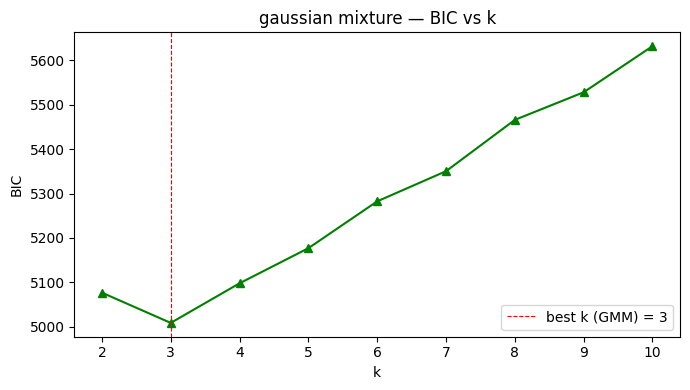

KMeans silhouette best k: 2
GMM BIC best k          : 3


In [7]:
from sklearn.mixture import GaussianMixture

bics = []
for k in ks:
    gm = GaussianMixture(n_components=k, random_state=42, n_init=5).fit(X_scaled)
    bics.append(gm.bic(X_scaled))  # Bayesian Information Criterion: balances fit vs complexity

best_k_gmm = ks[int(np.argmin(bics))]  # k with lowest BIC

plt.figure(figsize=(7, 4))
plt.plot(ks, bics, "g^-")
plt.axvline(best_k_gmm, color="red", linestyle="--", linewidth=0.8,
            label=f"best k (GMM) = {best_k_gmm}")
plt.xlabel("k"); plt.ylabel("BIC")
plt.title("gaussian mixture — BIC vs k")
plt.legend()
plt.tight_layout()
plt.show()

print("KMeans silhouette best k:", best_k)
print("GMM BIC best k          :", best_k_gmm)

## choosing k = 3

In [8]:
chosen_k = 3  # policy-relevant segmentation (GMM-supported), richer than the k=2 size split
print(f"silhouette-optimal k = {best_k}, GMM-optimal k = {best_k_gmm}, chosen k = {chosen_k}")

silhouette-optimal k = 2, GMM-optimal k = 3, chosen k = 3


## fit final model

In [9]:
km_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
df["cluster"] = km_final.fit_predict(X_scaled)
print("silhouette :", silhouette_score(X_scaled, df["cluster"]))
print("davies-bouldin:", davies_bouldin_score(X_scaled, df["cluster"]))      # lower = better
print("calinski-harabasz:", calinski_harabasz_score(X_scaled, df["cluster"]))  # higher = better

silhouette : 0.37929448769641894
davies-bouldin: 1.4674851960446362
calinski-harabasz: 295.0061599997388


## cluster sizes

In [10]:
print(df["cluster"].value_counts().sort_index())

cluster
0    112
1     74
2    314
Name: count, dtype: int64


## pca visualisation

explained variance: 71.33%


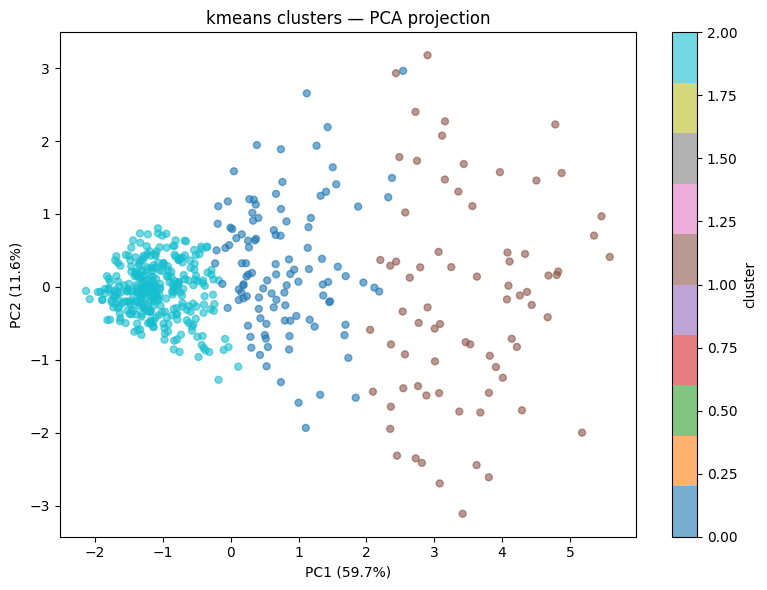

In [11]:
pca = PCA(n_components=2, random_state=42)  # 2D projection for visual cluster separation
X_pca = pca.fit_transform(X_scaled)

print(f"explained variance: {pca.explained_variance_ratio_.sum():.2%}")  # variance retained by 2 PCs

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df["cluster"], cmap="tab10", alpha=0.6, s=25)
plt.colorbar(scatter, label="cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("kmeans clusters — PCA projection")
plt.tight_layout()
plt.show()

Clusters separate fairly cleanly in 2D.

## cluster profile

In [12]:
profile = df.groupby("cluster")[feature_cols + ["household_size", "estimated_co2_kg_per_month"]].mean().round(2)  # per-cluster feature means
profile

,energy_per_person,car_per_person,meat_per_person,food_per_person,gas_per_person,household_size,estimated_co2_kg_per_month
cluster,,,,,,,
0,378.76,541.33,5.47,566.72,52.56,1.76,1496.97
1,760.30,1240.20,11.12,829.45,78.56,1.00,1626.68
2,182.97,255.57,2.66,227.36,18.53,3.87,1420.94


The clusters split mainly by **household size / per-capita intensity**, not by total CO2 — note total emissions are similar across clusters. So carbon level cuts across household types rather than defining them.

## cluster profile heatmap

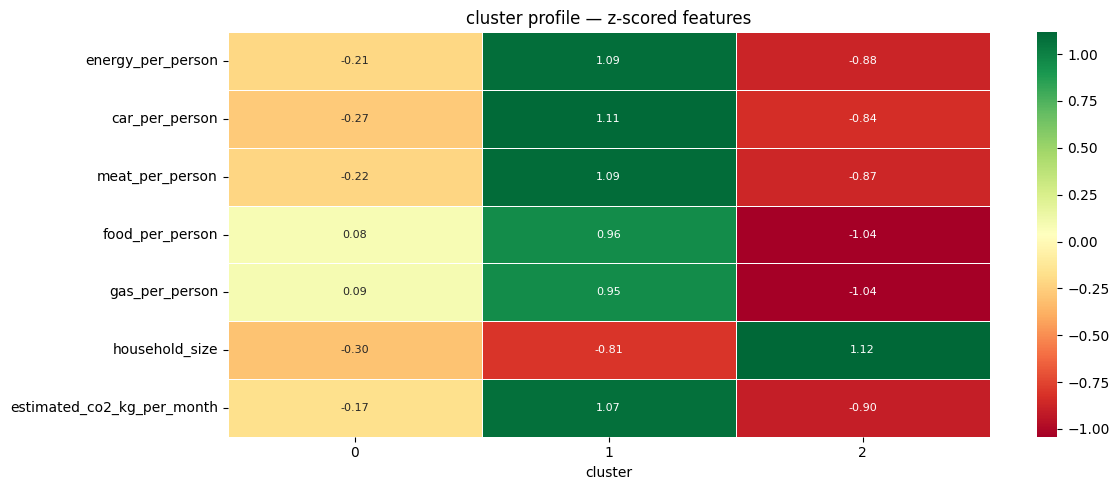

In [13]:
# z-score the profile for cross-feature comparison
profile_z = (profile - profile.mean()) / profile.std()  # z-score: cross-feature comparison on same scale

plt.figure(figsize=(12, 5))
sns.heatmap(profile_z.T, annot=True, fmt=".2f",
            cmap="RdYlGn", linewidths=0.5, annot_kws={"size": 8})
plt.title("cluster profile — z-scored features")
plt.tight_layout()
plt.show()

## cluster vs carbon level

<Figure size 700x400 with 0 Axes>

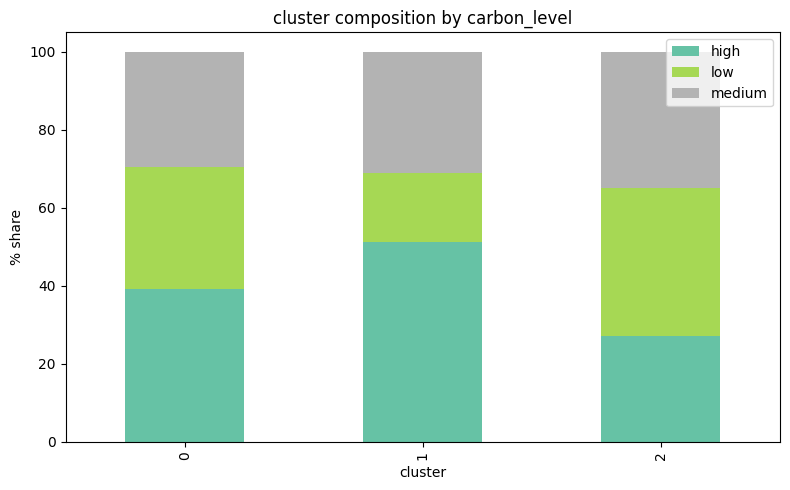

In [14]:
plt.figure(figsize=(7, 4))
ct = pd.crosstab(df["cluster"], df["carbon_level"], normalize="index") * 100  # row-normalised: % breakdown per cluster
ct.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.ylabel("% share")
plt.title("cluster composition by carbon_level")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Carbon levels are mixed within each cluster — clustering captures lifestyle type, not emission level.

## shap — kernel explainer on cluster centroids

In [15]:
from sklearn.pipeline import make_pipeline

def cluster_predict_proba(X_arr):  # soft membership via inverse centroid distance
    distances = km_final.transform(X_arr)
    inv = 1.0 / (distances + 1e-9)  # 1e-9 epsilon avoids division by zero
    return inv / inv.sum(axis=1, keepdims=True)

background  = shap.kmeans(X_scaled, 10)  # KMeans summary as SHAP background distribution
explainer_k = shap.KernelExplainer(cluster_predict_proba, background)
shap_vals_k = explainer_k.shap_values(X_scaled[:80], nsamples=100)  # 80-sample subset; KernelExplainer is O(n²)

  0%|          | 0/80 [00:00<?, ?it/s]

## shap — beeswarm per cluster

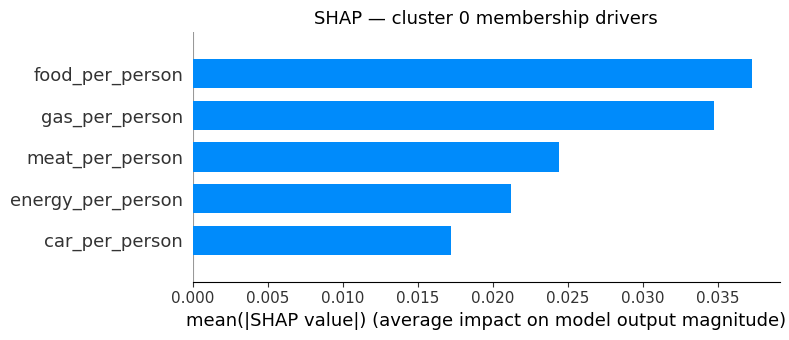

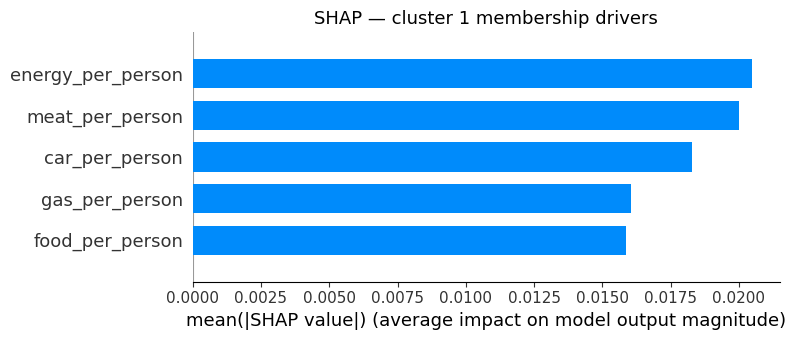

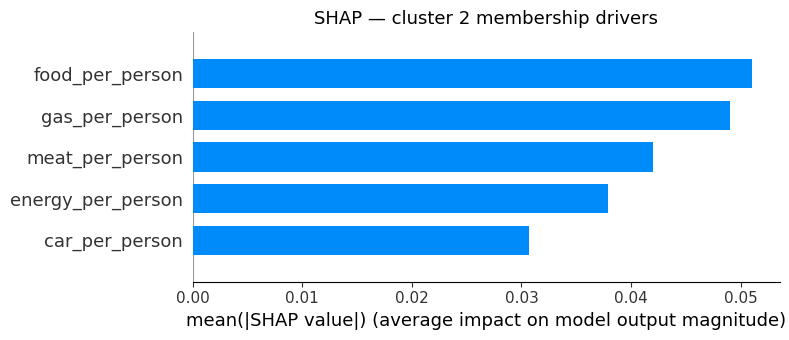

In [16]:
for c in range(chosen_k):
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.sca(ax)
    shap.summary_plot(
        shap_vals_k[:, :, c],
        pd.DataFrame(X_scaled[:80], columns=feature_cols),
        plot_type="bar", max_display=len(feature_cols), show=False
    )
    ax.set_title(f"SHAP — cluster {c} membership drivers", fontsize=13)
    plt.tight_layout()
    plt.show()